In [23]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 4
lag_num         = 4

config = EpiConfig(
    disease             = disease_name,
    target_column='cases',

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    # quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    feature_popsize     =True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )



for col incidence_lag1: reference: incidence_lag0
for col incidence_lag2: reference: incidence_lag0
for col incidence_lag3: reference: incidence_lag0


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/dataloading/epidataorchestration/epidataorchestrator_children.py:1157: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(int)


In [24]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)



graphdataloader_1       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test1').build()
graphdataloader_2       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test2').build()
graphdataloader_3     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test3').build()

from src.models import LSTMModel
from src.dataloading import DeepDataLoaderManager

deepdataloader     = DeepDataLoaderManager(epidata_orchestrator).build()
graphdataloader_4     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test4').build()


In [25]:
from src.models import SimpleGCNModel, GCNTCNModel

In [26]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

# climateology = ClimateologyModel(baselinedata)
# climateology.forecast()

# climascale = ClimaScaleModel(baselinedata)
# climascale.forecast()

baseline_models = [persistence]


==                    model1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 4), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |  -2.6862   |  -13.5736  |    v     |           |
|  002  |  -5.2366   |  -16.7389  |    v     |           |
|  003  |  -6.3686   |  -18.7744  |    v     |           |
|  004  |  -7.1527   |  -19.9878  |    v     |           |
|  005  |  -7.6316   |  -20.8302  |    v     |           |
|  006  |  -7.9866   |  -21.5048  |    v     |           |
|  007  |  -8.2380   |  -21.9200  |    v     |           |
|  008  |  -8.4129   |  -22.3560  |    v     |           |
|  009  |  -8.5613   |  -22.6050  |    v     |           |
|  010  |  -8.7066   |  -22.7140  |    v     |           |
|  011  |  -8.8142   |  -22.8304  |    v     |           |
|  012  |  -8.8560   |  -23.0750  |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  100  |  -10.0616  |  -25.1326  |    v     |           |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 430.60it/s]

Test loss: -25.2780
forecasted ✓


GCNTCNModel(name='model1')

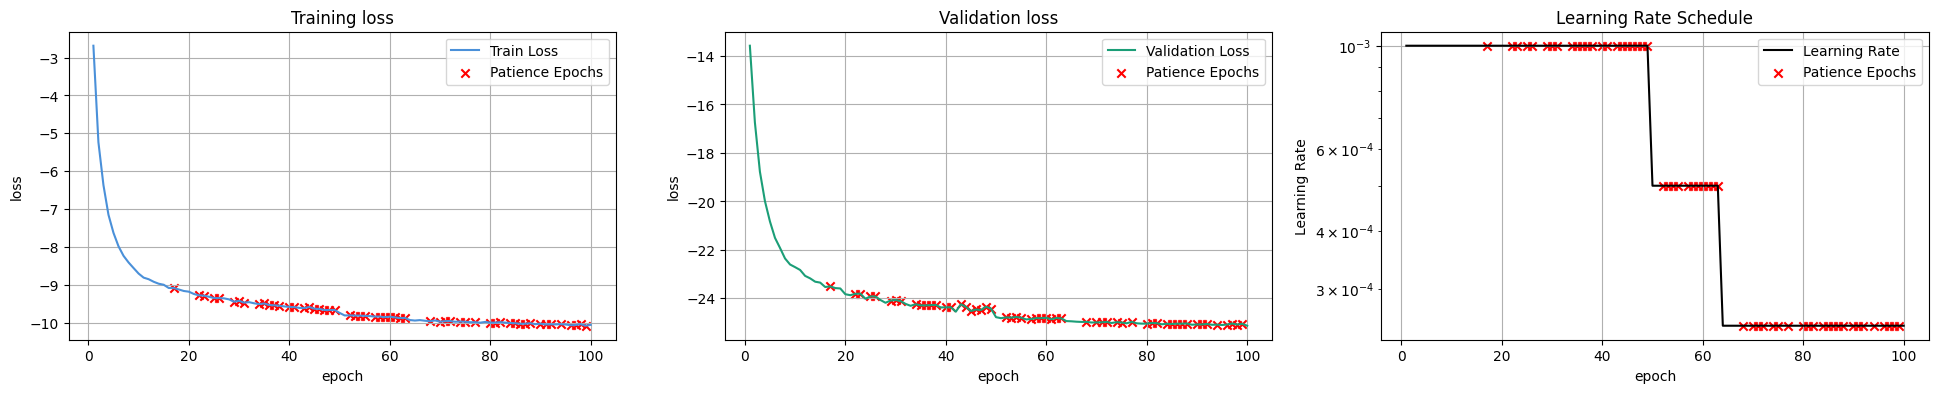

In [30]:
n_epochs        = 100
lr              = 0.001
min_delta       = 0.0001
loss            = 'poisson'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

ml1 = GCNTCNModel(graphdataloader_1, name = 'model1',verbose = 2)
ml1.set_model_hparams(norm_edges=True)
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast()

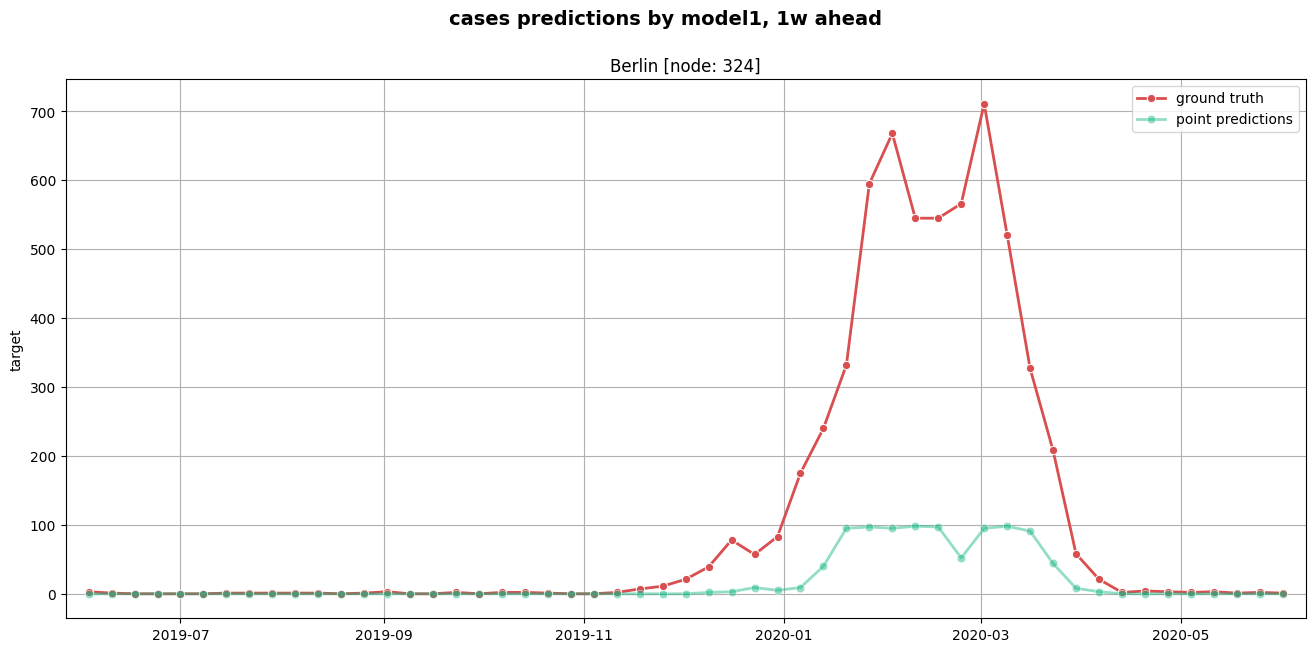

In [33]:
ml1.show_forecasts(324).show()


==                   model1+                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.1801   |   0.1272   |    v     |           |
|  002  |   0.1222   |   0.1249   |    v     |           |
|  003  |   0.1145   |   0.1252   |          |   1/20    |
|  004  |   0.1084   |   0.1235   |    v     |           |
|  005  |   0.1056   |   0.1207   |    v     |           |
|  006  |   0.1009   |   0.1197   |    v     |           |
|  007  |   0.0993   |   0.1203   |          |   1/20    |
|  008  |   0.0992   |   0.1195   |    v     |           |
|  009  |   0.0983   |   0.1186   |    v     |           |


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  010  |   0.0968   |   0.1190   |          |   1/20    |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 272.13it/s]


Test loss: 0.0417
forecasted ✓


GCNTCNModel(name='model1+')

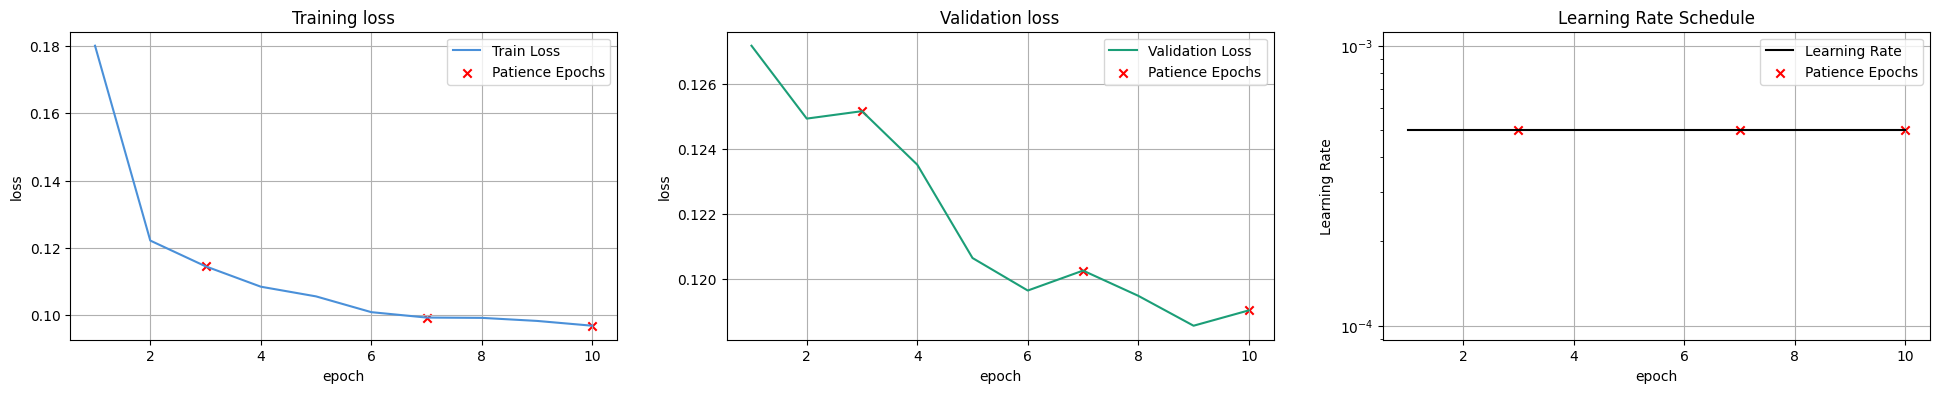

In [14]:
ml2 = GCNTCNModel(graphdataloader_1, name = 'model1+',verbose = 2)
ml2.set_model_hparams(self_loops=True, norm_edges=True)
ml2.set_global_hparams(**global_hparams)
ml2.train()
ml2.forecast()


==                    model3                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.0950   |   1.2912   |    v     |           |
|  002  |   0.8682   |   0.9917   |    v     |           |
|  003  |   0.7745   |   0.8951   |    v     |           |
|  004  |   0.7147   |   0.8420   |    v     |           |
|  005  |   0.6714   |   0.7979   |    v     |           |
|  006  |   0.6425   |   0.7674   |    v     |           |
|  007  |   0.6256   |   0.7373   |    v     |           |
|  008  |   0.6088   |   0.7096   |    v     |           |
|  009  |   0.5914   |   0.6881   |    v     |           |
|  010  |   0.5860   |   0.6675   |    v     |           |
|  011  |   0.5756   |   0.6502   |    v     |           |
|  012  |   0.5649   |   0.6353   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4837
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 450.31it/s]

Test loss: 0.7391
forecasted ✓


GCNTCNModel(name='model3')

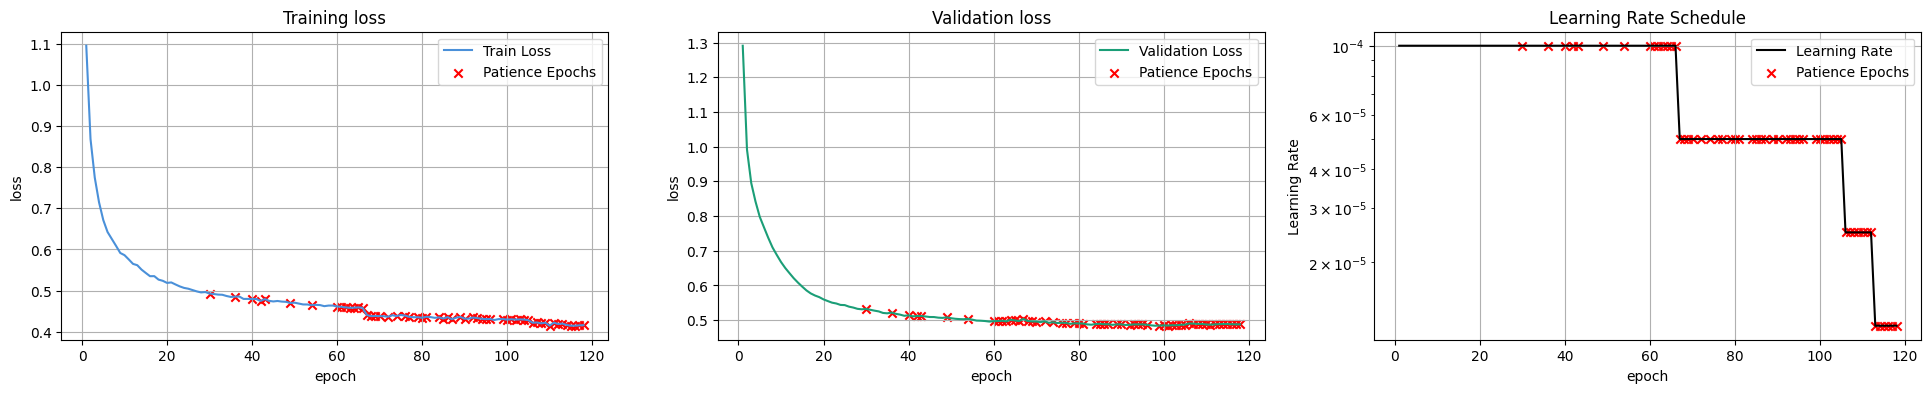

In [12]:
ml3 = GCNTCNModel(graphdataloader_2, name = 'model3',verbose = 2)
ml3.set_model_hparams(norm_edges=True)
ml3.set_global_hparams(**global_hparams)
ml3.train()
ml3.forecast()


==                    model4                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.0206   |   1.3193   |    v     |           |
|  002  |   0.8147   |   1.0387   |    v     |           |
|  003  |   0.7369   |   0.9129   |    v     |           |
|  004  |   0.6804   |   0.8347   |    v     |           |
|  005  |   0.6460   |   0.7856   |    v     |           |
|  006  |   0.6148   |   0.7491   |    v     |           |
|  007  |   0.5930   |   0.7213   |    v     |           |
|  008  |   0.5783   |   0.7009   |    v     |           |
|  009  |   0.5643   |   0.6801   |    v     |           |
|  010  |   0.5508   |   0.6628   |    v     |           |
|  011  |   0.5441   |   0.6519   |    v     |           |
|  012  |   0.5342   |   0.6375   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4680
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 454.26it/s]

Test loss: 0.7159
forecasted ✓


GCNTCNModel(name='model4')

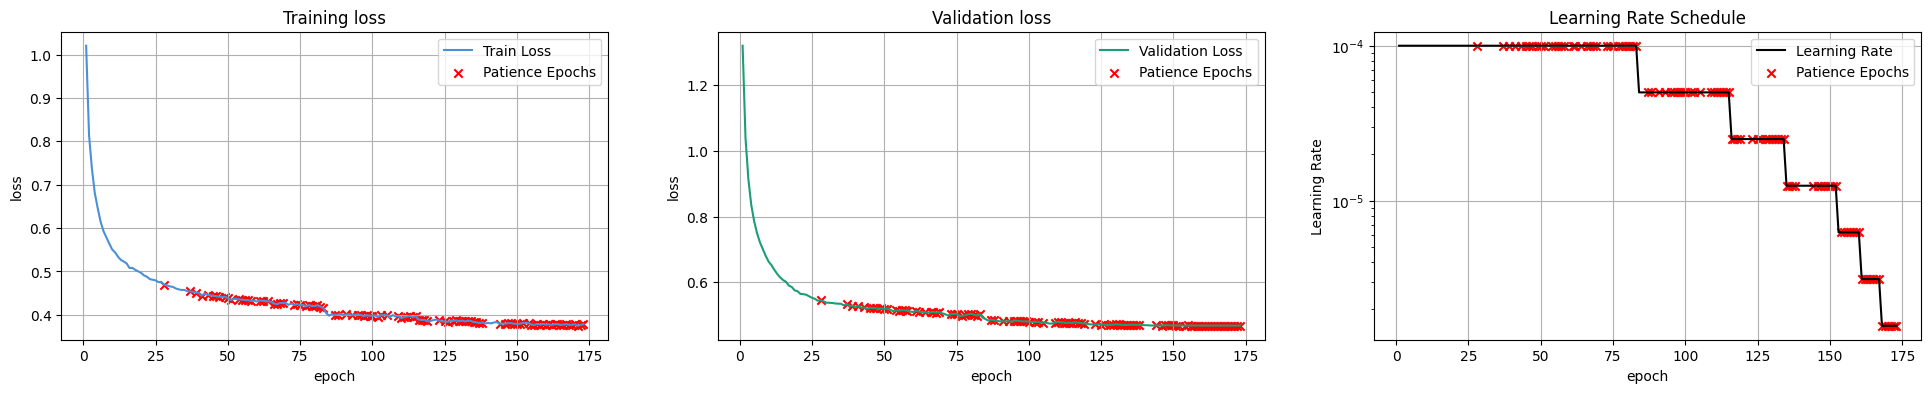

In [13]:
ml4 = GCNTCNModel(graphdataloader_3, name = 'model4',verbose = 2)
ml4.set_model_hparams(norm_edges = True)
ml4.set_global_hparams(**global_hparams)
ml4.train()
ml4.forecast()


==                    model5                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 25, 4), y=(400, 1), edge_index=(2, 160000), edge_weight=(160000,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.0893   |   1.2841   |    v     |           |
|  002  |   0.8730   |   1.0376   |    v     |           |
|  003  |   0.7819   |   0.9497   |    v     |           |
|  004  |   0.7269   |   0.8826   |    v     |           |
|  005  |   0.6892   |   0.8263   |    v     |           |
|  006  |   0.6608   |   0.7833   |    v     |           |
|  007  |   0.6403   |   0.7452   |    v     |           |
|  008  |   0.6245   |   0.7127   |    v     |           |
|  009  |   0.6125   |   0.6878   |    v     |           |
|  010  |   0.6050   |   0.6694   |    v     |           |
|  011  |   0.5939   |   0.6546   |    v     |           |
|  012  |   0.5875   |   0.6421   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5625
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 439.59it/s]

Test loss: 0.7939
forecasted ✓


GCNTCNModel(name='model5')

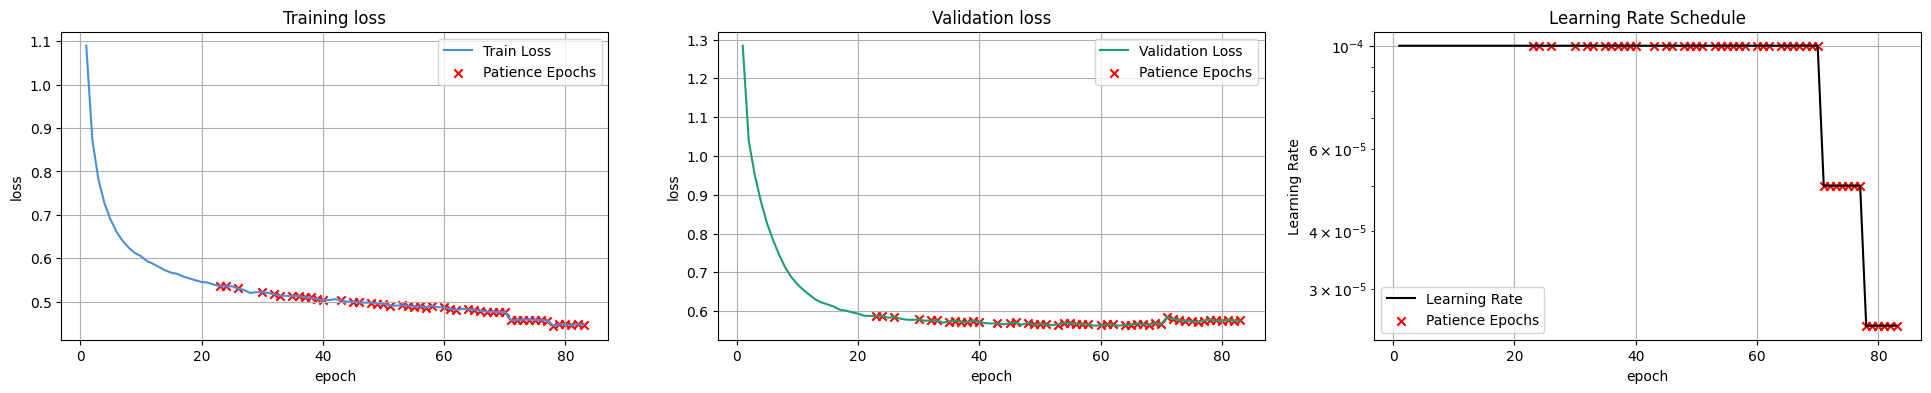

In [14]:
ml5 = GCNTCNModel(graphdataloader_4, name = 'model5',verbose = 2)
ml5.set_model_hparams()
ml5.set_global_hparams(**global_hparams)
ml5.train()
ml5.forecast()


==                    model6                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 25, 4), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.0892   |   1.6450   |    v     |           |
|  002  |   0.8275   |   1.0824   |    v     |           |
|  003  |   0.8640   |   1.0042   |    v     |           |
|  004  |   0.7325   |   0.8479   |    v     |           |
|  005  |   0.7056   |   0.7823   |    v     |           |
|  006  |   0.6475   |   0.7131   |    v     |           |
|  007  |   0.6169   |   0.6743   |    v     |           |
|  008  |   0.5838   |   0.6396   |    v     |           |
|  009  |   0.5622   |   0.6134   |    v     |           |
|  010  |   0.5402   |   0.5953   |    v     |           |
|  011  |   0.5288   |   0.5833   |    v     |           |
|  012  |   0.5213   |   0.5726   |    v     |           |
|  013  |   0.5108   | 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4843
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 834.44it/s]

Test loss: 0.6958
forecasted ✓


LSTMModel(name='model6')

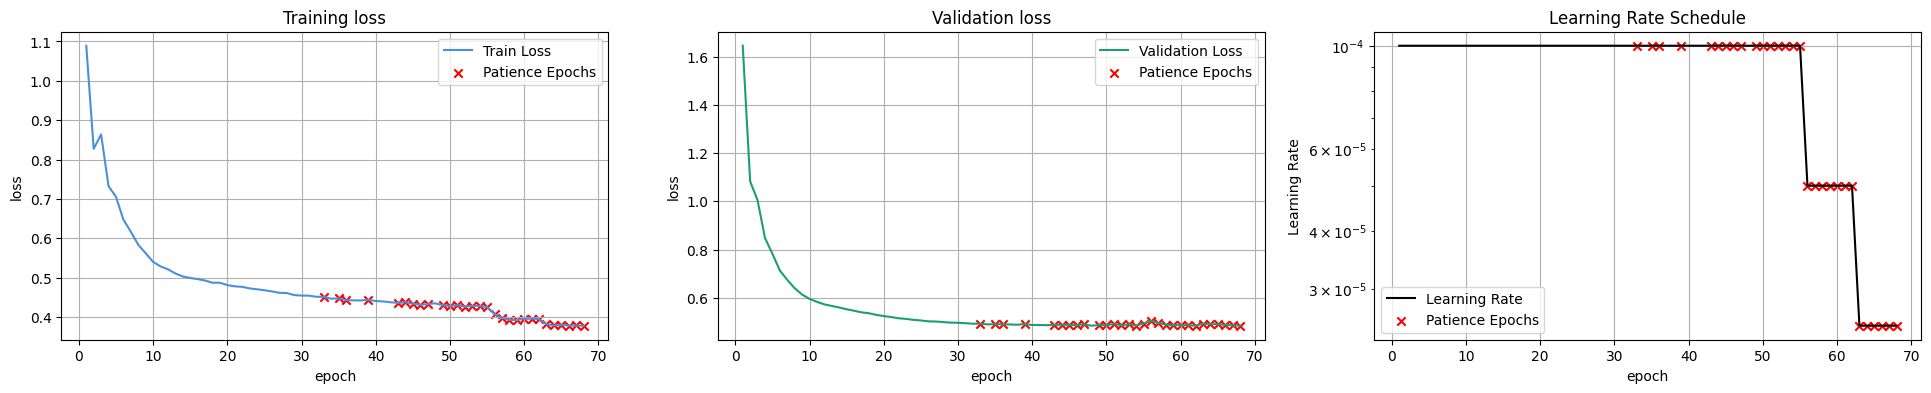

In [15]:
ml5 = LSTMModel(deepdataloader, name = 'model6',verbose = 2)
ml5.set_model_hparams()
ml5.set_global_hparams(**global_hparams)
ml5.train()
ml5.forecast()

In [16]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [ml1, ml2, ml3, ml4, ml5]).add_evaluation()


  0%|                                                                                                                                                                                | 0/2400 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:00<00:00, 3232.15it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


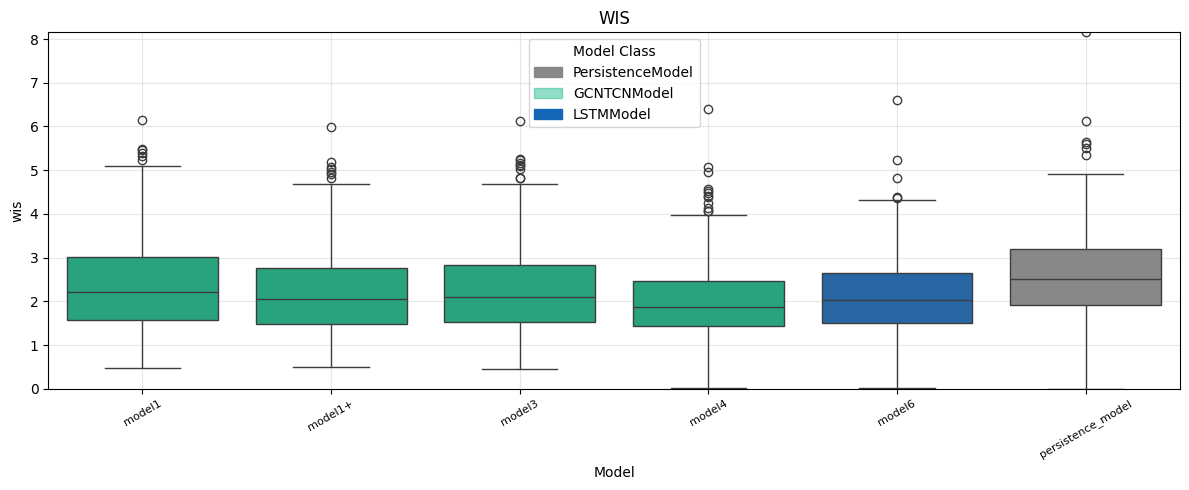

In [20]:
f = evaluation_experiment_sgnn.plotter.plot_single_metric('wis',0,plot_type = 'box',reverse_scale=True)
f.show()


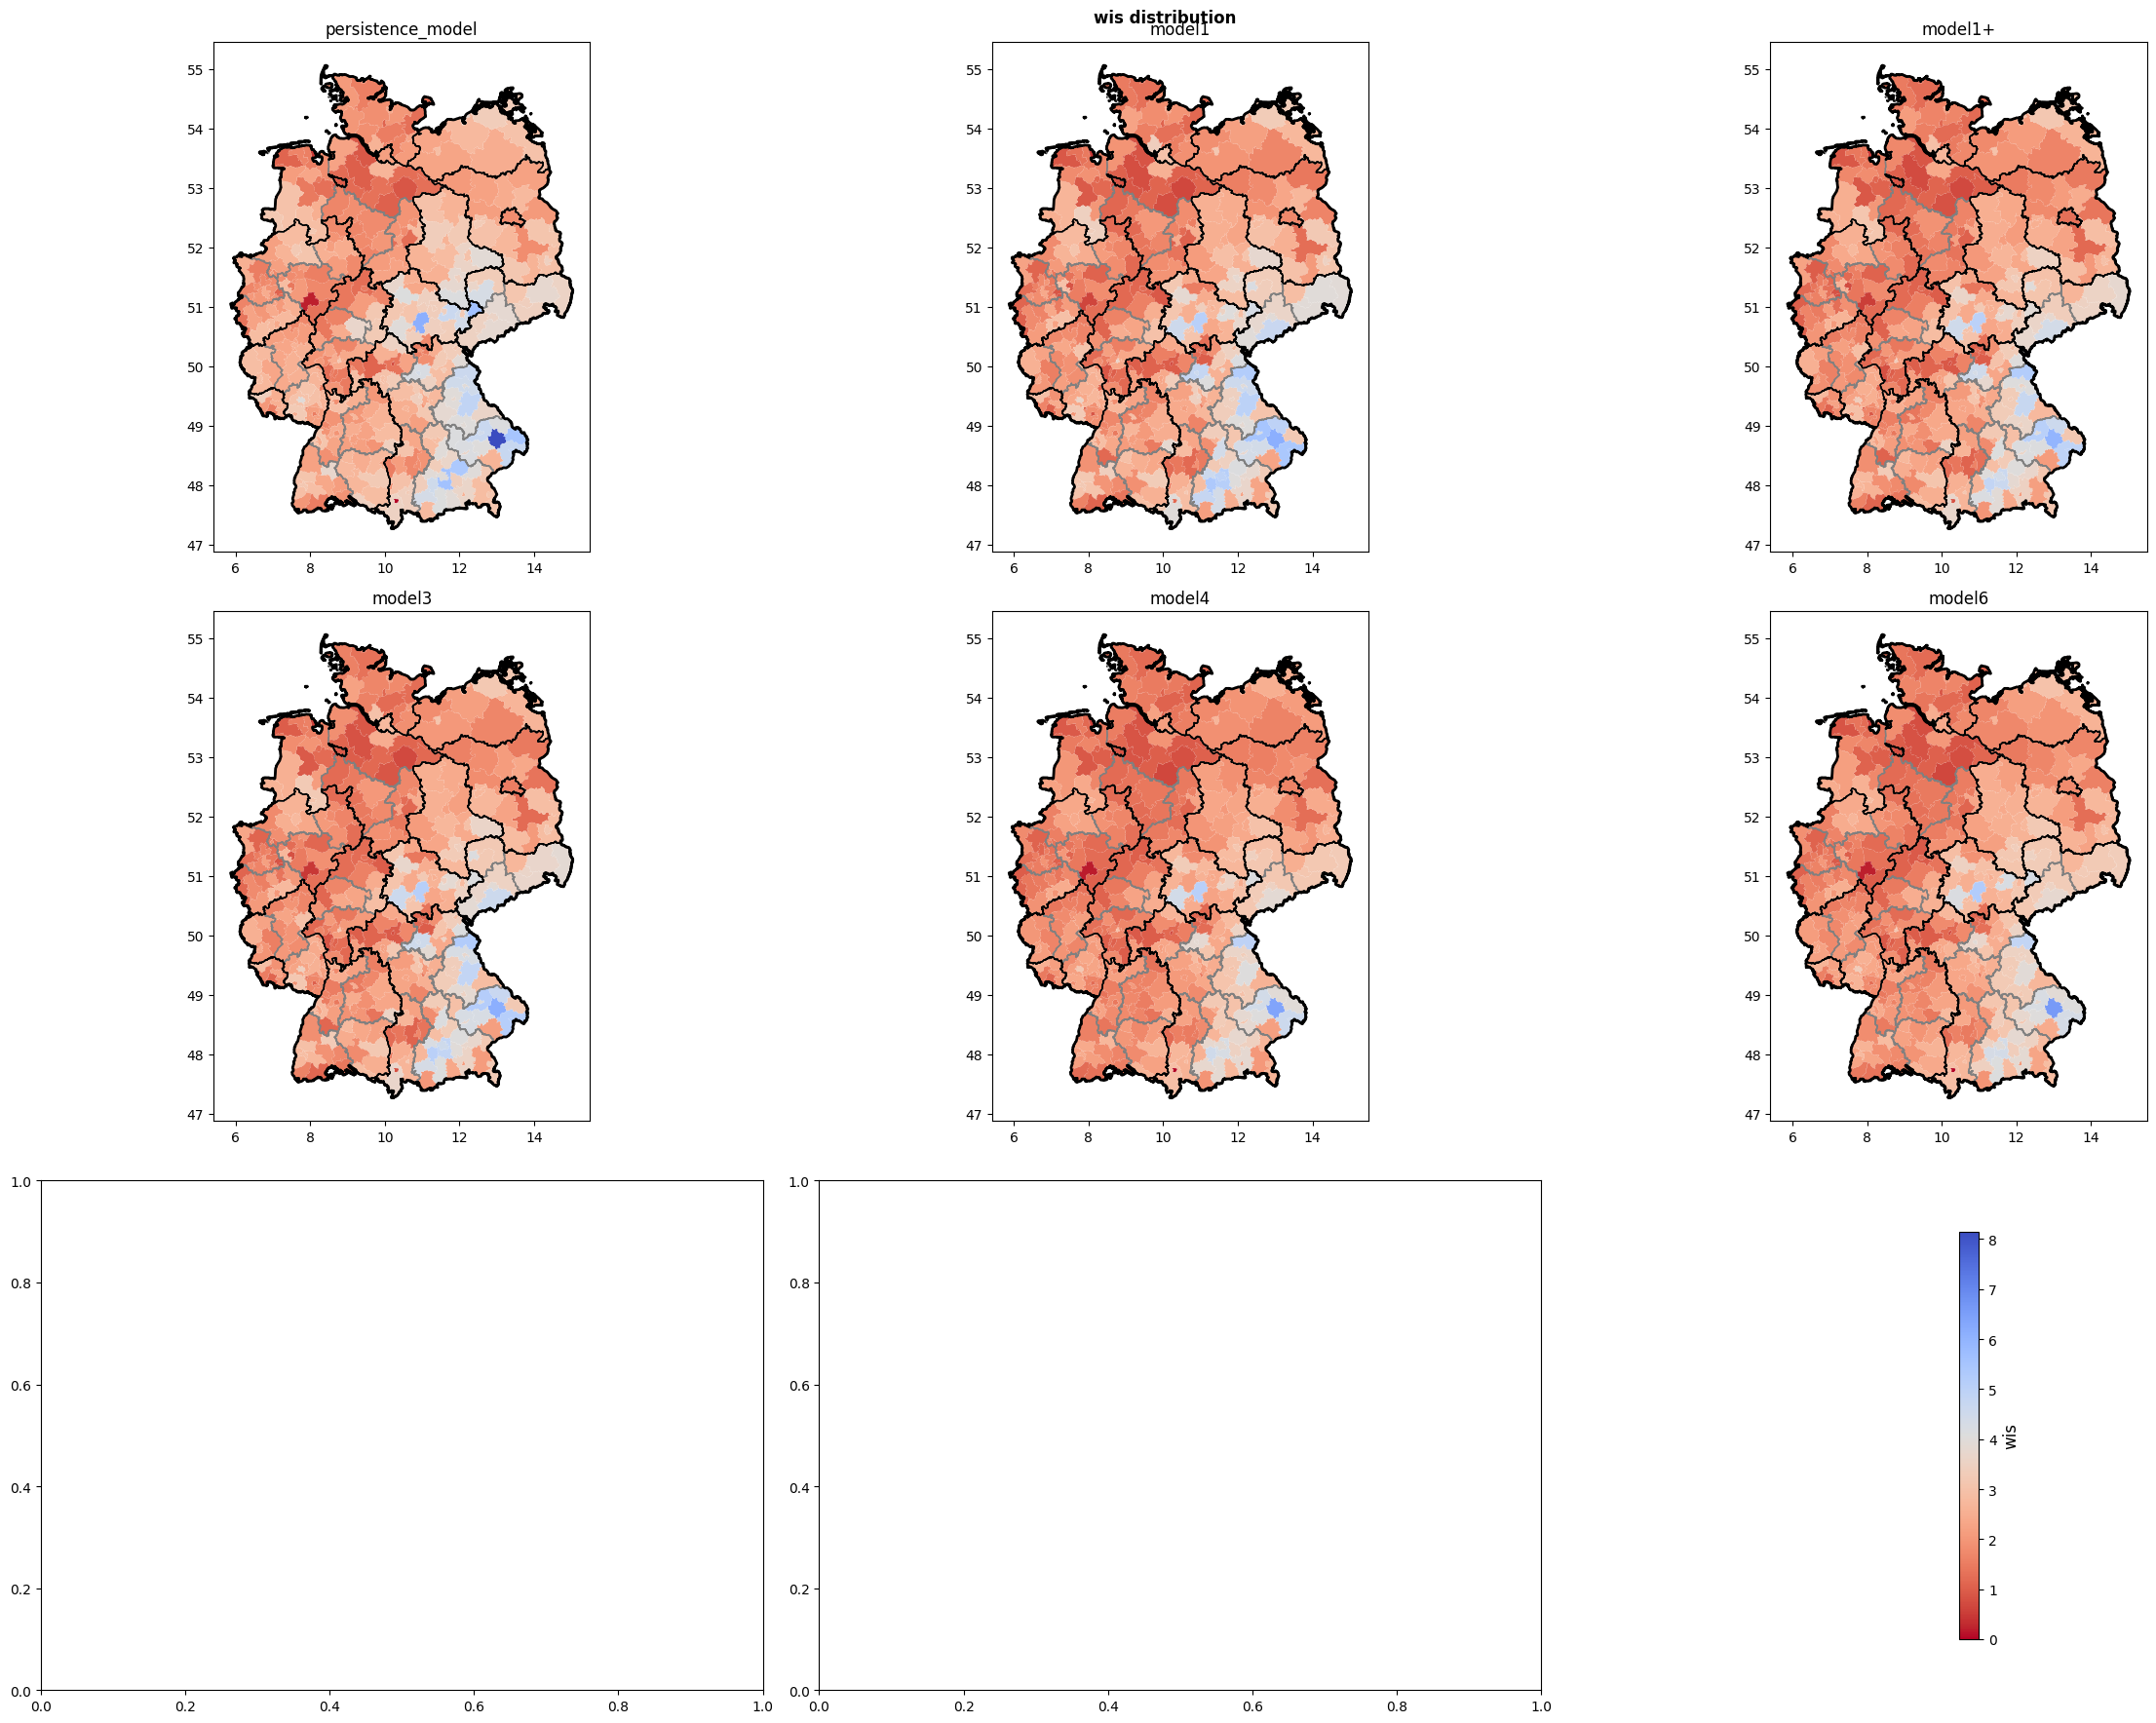

In [17]:
evaluation_experiment_sgnn.plotter.plot_single_metric('wis',0,plot_type = 'map',reverse_scale=True,vmin = 0)

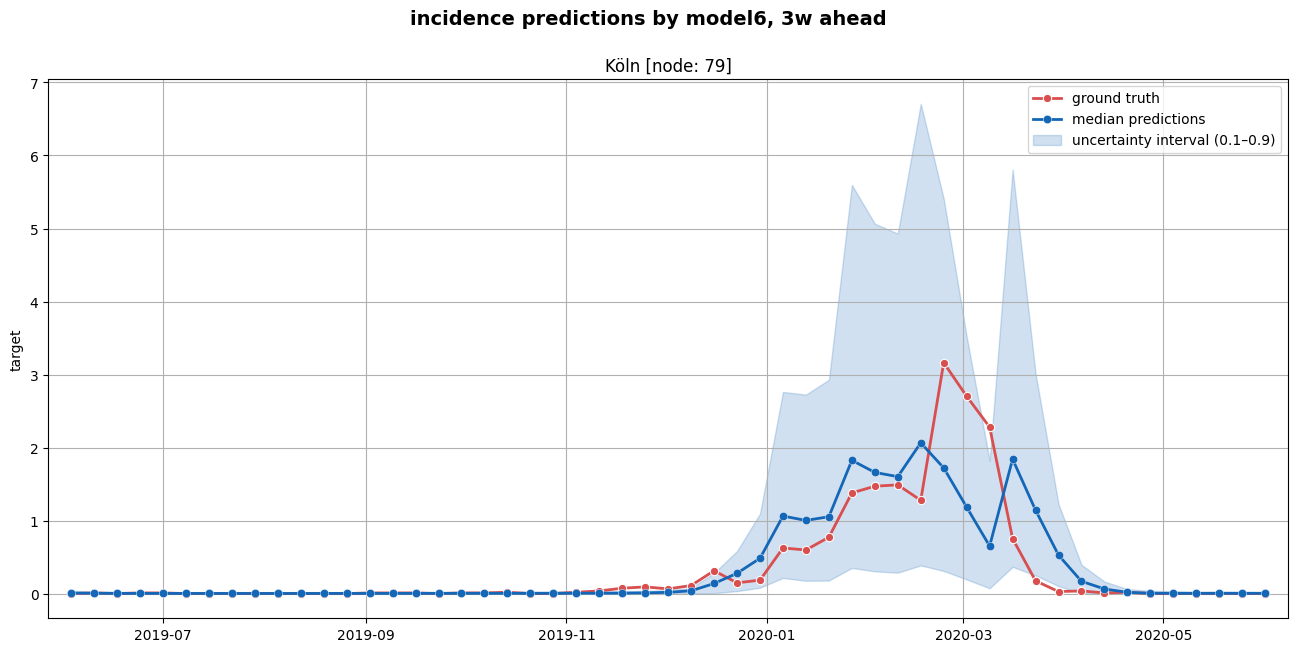

In [37]:
ml5.show_forecasts(79).show()

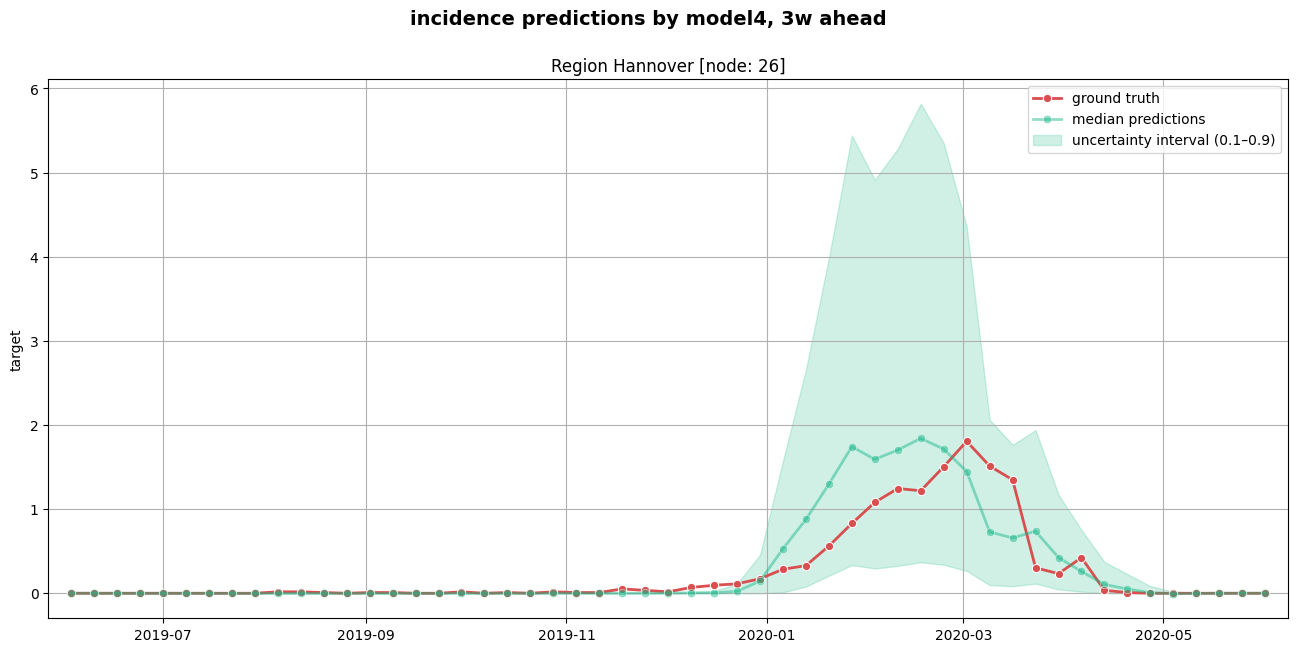

In [21]:
ml4.show_forecasts(26).show()

In [18]:
df = evaluation_experiment_sgnn.data_compilation.get_data(0,'test')['metrics']
df_comp = df[df['model'].isin(['model3','model6'])][['nuts_node','model','r2','ccc']]
df_comp_ccc = df_comp[['nuts_node','model','ccc']].pivot_table(index = 'nuts_node', columns = 'model', values = 'ccc').reset_index(drop = False)
df_comp_r2 = df_comp[['nuts_node','model','r2']].pivot_table(index = 'nuts_node', columns = 'model', values = 'r2').reset_index(drop = False)

df_comp_ccc['diff'] = 100 * (df_comp_ccc['model3'] - df_comp_ccc['model6']) / df_comp_ccc['model3']
df_comp_r2['diff'] = 100 * (df_comp_r2['model3'] - df_comp_r2['model6']) / df_comp_r2['model3']

gdf = epidata_orchestrator.data_context.shapedata_node
import pandas as pd
df_comp_ccc = pd.merge(gdf, df_comp_ccc, on = 'nuts_node')
df_comp_r2 = pd.merge(gdf, df_comp_r2, on = 'nuts_node')

KeyError: "['r2', 'ccc'] not in index"

<Axes: >

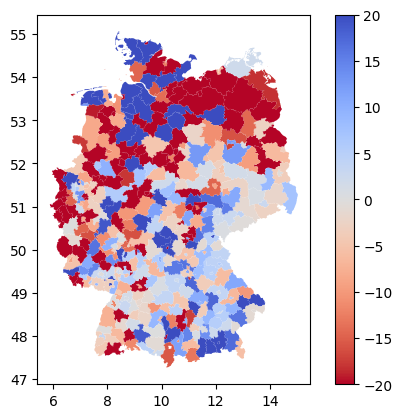

In [ ]:
df_comp_r2.plot(column = 'diff', cmap = 'coolwarm_r', vmin = -20, vmax = 20, legend = True)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd 
import geopandas as gpd

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

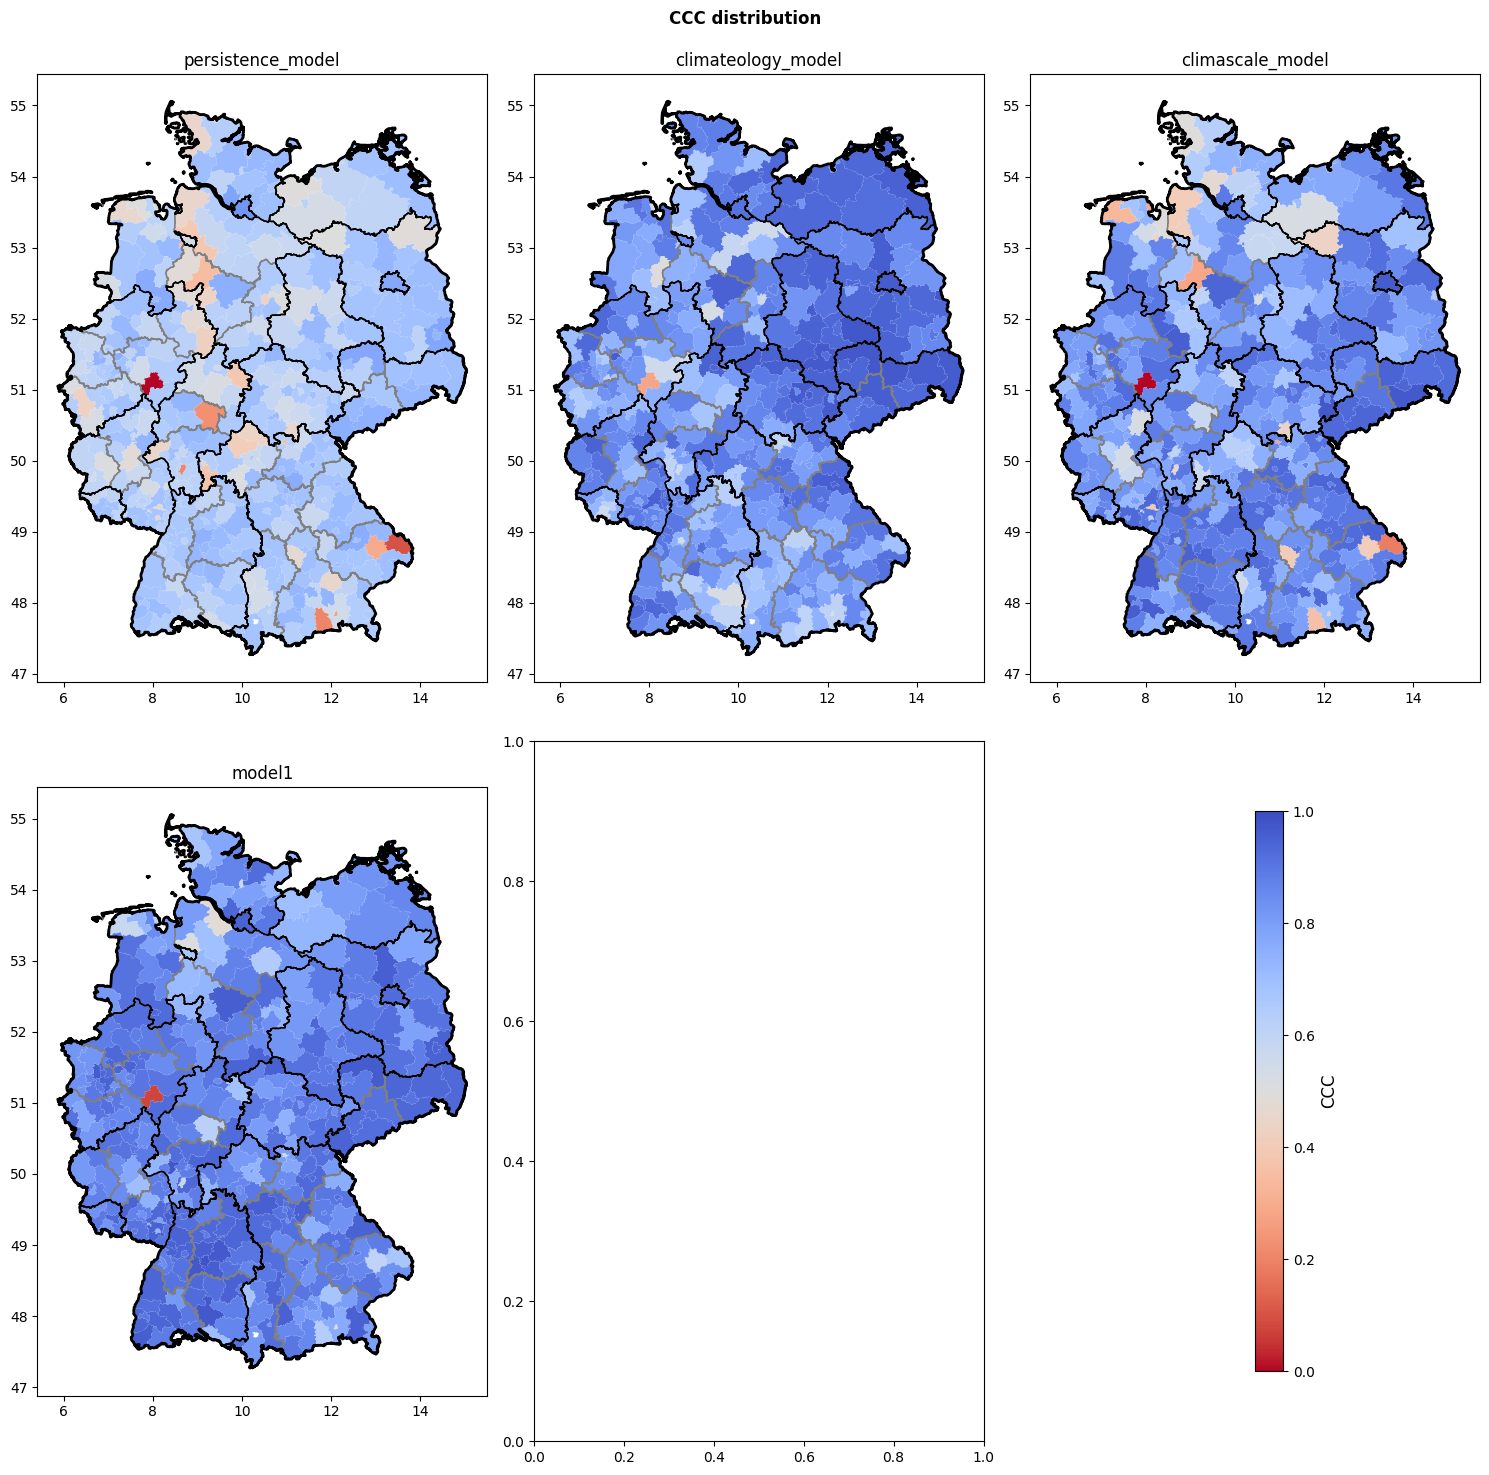

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = ccc

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=0,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('CCC', fontsize=12)

fig.suptitle('CCC distribution', fontweight = 'bold')

plt.tight_layout()
plt.show()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

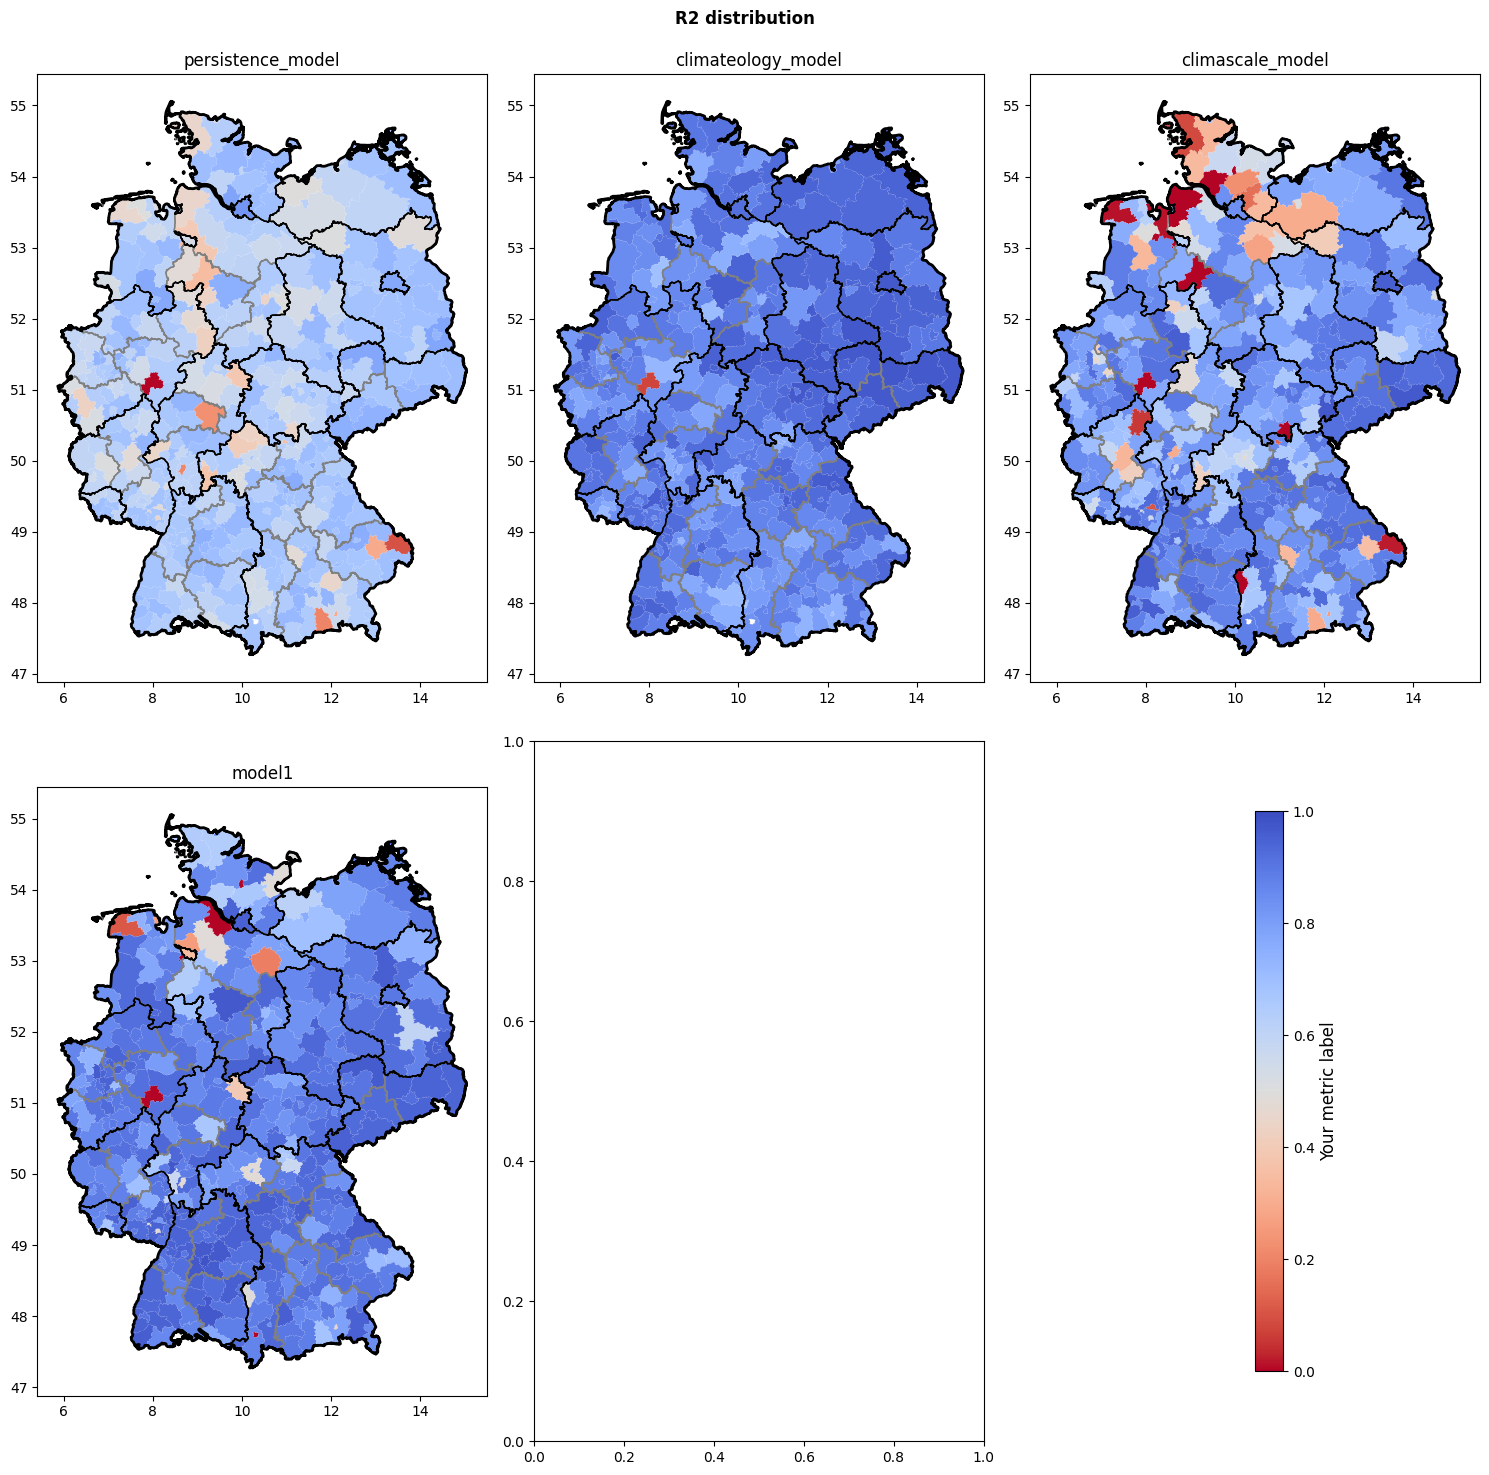

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = r2

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=-1,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('Your metric label', fontsize=12)

fig.suptitle('R2 distribution',fontweight = 'bold')
plt.tight_layout()
plt.show()